<a href="https://colab.research.google.com/github/JJulianOlivera/educursos/blob/main/Homework_L2_Regresion_RetailBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# 1. Cargar el dataset específico de regresión
df = pd.read_csv('retailboost_customers_regression.csv')

# 2. Exploración básica
print("Dimensiones del dataset")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\nVerificación de Nulos")
print(df.isnull().sum())

# Descarta customer_id por no tener valor predictivo
df_clean = df.drop(columns=['customer_id'])

display(df_clean.head())

Dimensiones del dataset
Filas: 500, Columnas: 7

Verificación de Nulos
customer_id           0
age                   0
income                0
visits_per_month      0
satisfaction_score    0
membership_years      0
monthly_spent         0
dtype: int64


,age,income,visits_per_month,satisfaction_score,membership_years,monthly_spent
0,56,5122.16,8,4,9,2555.68
1,69,4032.47,7,5,0,1737.75
2,46,1480.63,9,4,13,1031.05
3,32,2515.77,7,1,2,730.76
4,60,4266.91,12,1,13,1496.51


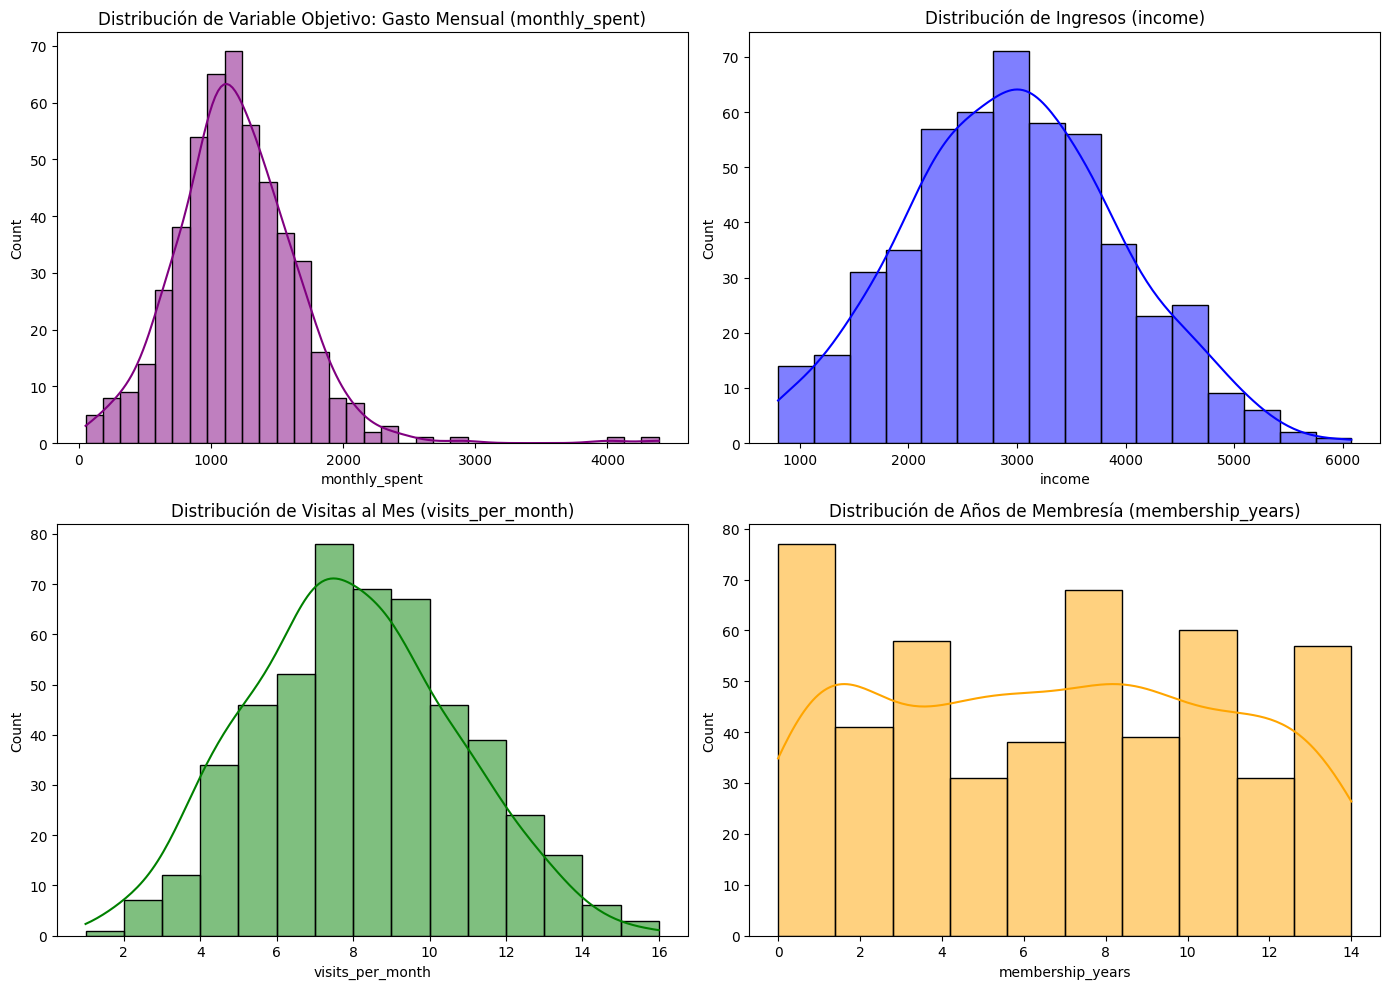

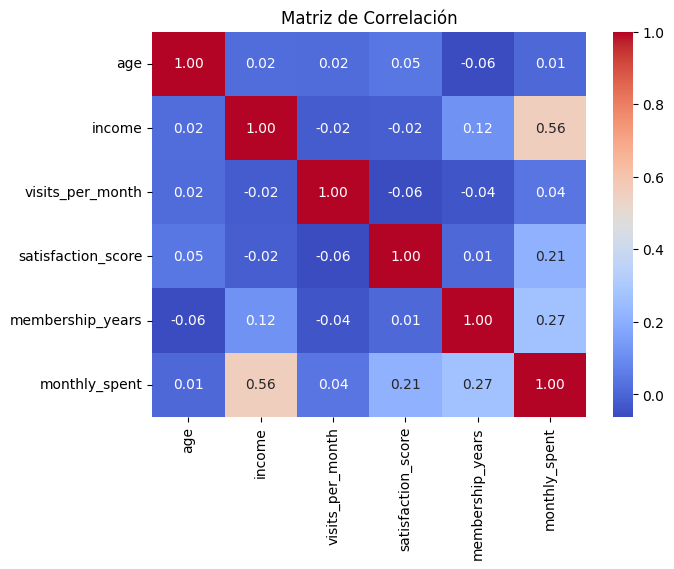

In [2]:
# Graficar distribuciones clave
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Variable Objetivo: Gasto Mensual
sns.histplot(df_clean['monthly_spent'], kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Distribución de Variable Objetivo: Gasto Mensual (monthly_spent)')

# Predictor 1: Ingresos
sns.histplot(df_clean['income'], kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Distribución de Ingresos (income)')

# Predictor 2: Visitas al mes
sns.histplot(df_clean['visits_per_month'], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribución de Visitas al Mes (visits_per_month)')

# Predictor 3: Antigüedad de membresía
sns.histplot(df_clean['membership_years'], kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Distribución de Años de Membresía (membership_years)')

plt.tight_layout()
plt.show()

# Gráfico de Correlación rápido para entender las relaciones
plt.figure(figsize=(7, 5))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

In [3]:
# 1. Define variables predictoras y objetivo
X = df_clean.drop(columns=['monthly_spent'])
y = df_clean['monthly_spent']

# 2. Divide en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Datos listos para modelar. Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")

Datos listos para modelar. Train: 400 filas | Test: 100 filas


In [4]:
# 1. Selecciona la variable predictora principal para el modelo simple
X_train_simple = X_train[['income']]
X_test_simple = X_test[['income']]

# 2. Instanciar y entrenar el modelo
modelo_simple = LinearRegression()
modelo_simple.fit(X_train_simple, y_train)

# 3. Predicciones en Test
y_pred_simple = modelo_simple.predict(X_test_simple)

# 4. Cálculo de métricas obligatorias
r2_s = r2_score(y_test, y_pred_simple)
mae_s = mean_absolute_error(y_test, y_pred_simple)
rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_simple))

print("MODELO 1: REGRESIÓN LINEAL SIMPLE (Predictor: income)")
print(f"Intercepto (Beta_0): {modelo_simple.intercept_:.2f}")
print(f"Pendiente (Beta_1): {modelo_simple.coef_[0]:.4f}")
print(f"R² (Coeficiente de Determinación): {r2_s:.4f}")
print(f"MAE (Error Absoluto Medio): {mae_s:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_s:.2f}")

MODELO 1: REGRESIÓN LINEAL SIMPLE (Predictor: income)
Intercepto (Beta_0): 365.78
Pendiente (Beta_1): 0.2732
R² (Coeficiente de Determinación): 0.2236
MAE (Error Absoluto Medio): 273.41
RMSE (Raíz del Error Cuadrático Medio): 435.06


In [5]:
# 1. Instanciar y entrenar con TODAS las variables predictoras
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, y_train)

# 2. Predicciones en Test
y_pred_multiple = modelo_multiple.predict(X_test)

# 3. Cálculo de métricas obligatorias
r2_m = r2_score(y_test, y_pred_multiple)
mae_m = mean_absolute_error(y_test, y_pred_multiple)
rmse_m = np.sqrt(mean_squared_error(y_test, y_pred_multiple))

print("MODELO 2: REGRESIÓN LINEAL MÚLTIPLE")
print(f"R² (Coeficiente de Determinación): {r2_m:.4f}")
print(f"MAE (Error Absoluto Medio): {mae_m:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_m:.2f}")

# Mostrar coeficientes ordenados para ver qué variable influye más
importancias_reg = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente (Impacto)': modelo_multiple.coef_
}).sort_values(by='Coeficiente (Impacto)', ascending=False)

print("\nCoeficientes de la Regresión Múltiple")
display(importancias_reg)

MODELO 2: REGRESIÓN LINEAL MÚLTIPLE
R² (Coeficiente de Determinación): 0.3397
MAE (Error Absoluto Medio): 240.69
RMSE (Raíz del Error Cuadrático Medio): 401.21

Coeficientes de la Regresión Múltiple


,Variable,Coeficiente (Impacto)
3,satisfaction_score,71.498115
4,membership_years,21.940713
2,visits_per_month,14.754554
1,income,0.259377
0,age,0.081631


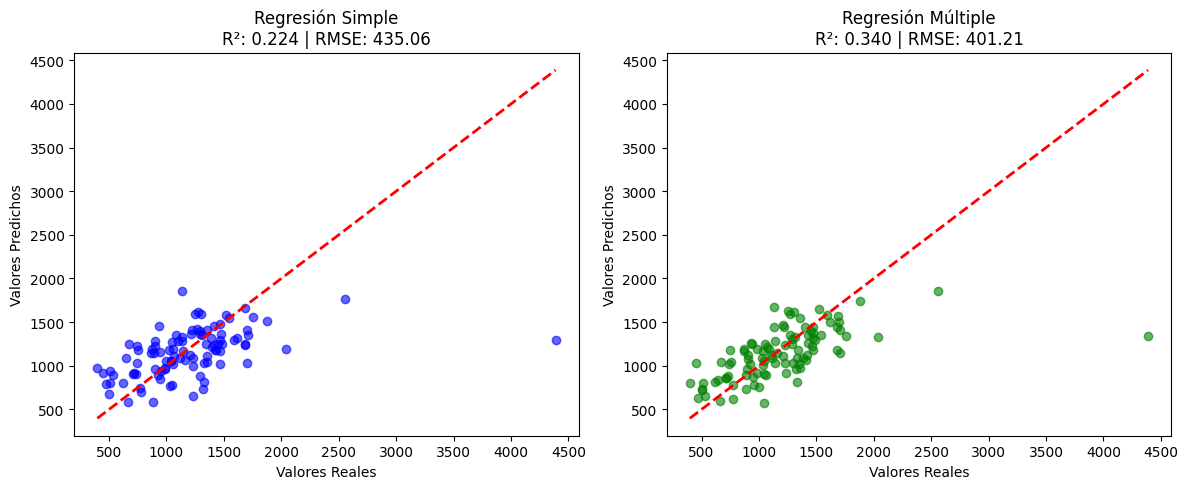

In [6]:
plt.figure(figsize=(12, 5))

# Subplot Modelo Simple
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_simple, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Regresión Simple\nR²: {r2_s:.3f} | RMSE: {rmse_s:.2f}')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')

# Subplot Modelo Múltiple
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_multiple, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Regresión Múltiple\nR²: {r2_m:.3f} | RMSE: {rmse_m:.2f}')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')

plt.tight_layout()
plt.show()

# Conclusiones del Análisis de Regresión (RetailBoost)

### 1. Evaluación de Rendimiento y Ajuste del Modelo
Al comparar los dos enfoques lineales, observamos un incremento significativo en la capacidad predictiva al pasar del modelo simple al múltiple:
* **Modelo Simple (Solo Ingresos):** Al usar únicamente el ingreso del cliente, el modelo arrojó un **R² de 0.2236** y un error promedio (MAE) de **$273.41**. Esto demuestra que el poder adquisitivo explica una porción del consumo, pero deja fuera demasiada variabilidad del comportamiento humano.
* **Modelo Múltiple (Contexto Completo):** Al incorporar la edad, las visitas, la antigüedad y la satisfacción, el **R² sube a 0.3397** (una mejora relativa de más del 50% en la varianza explicada) y el error promedio (MAE) desciende a **$240.69**.
* **Razonabilidad de los Errores:** En datos de comportamiento de retail real, un R² de 0.34 es un hallazgo valioso, ya que confirma la existencia de patrones de consumo verificables en un entorno dominado por el "ruido" y las decisiones impulsivas (variables que el modelo no puede medir, como gastos de emergencia o gustos personales).

### 2. Interpretación de las Variables (Motores de Gasto)
Al analizar la magnitud de los coeficientes en el modelo múltiple, descubrimos los factores reales que impulsan el ticket mensual:
1. **Poder Adquisitivo (income):** Aunque su coeficiente es de `0.259`, al multiplicarse por la escala de miles de dólares, es el factor de mayor peso volumétrico. Por cada $1000 dólares extra de salario, el cliente gasta aproximadamente **$259 dólares más** en la tienda.
2. **Nivel de Satisfacción (satisfaction_score):** Con un coeficiente de `71.49`, es la variable cualitativa más impactante. Por cada punto extra de satisfacción que logra la marca (en una escala típica de 1 a 5), el cliente aumenta su gasto mensual en más de $71 dólares.
3. **Fidelidad y Recurrencia:** La antigüedad (`membership_years`, coef: 21.94) y el tráfico a la web (`visits_per_month`, coef: 14.75) actúan como aceleradores orgánicos del gasto mensual.

### 3. Recomendaciones Estratégicas
* **Invertir en Experiencia del Cliente:** Dado que la satisfacción tiene un impacto directo y cuantificable en los ingresos (+$71 por punto), el equipo de Operaciones debe priorizar la resolución rápida de tickets de soporte y la calidad del envío.
* **Retención sobre Adquisición:** La antigüedad de la membresía suma casi $22 dólares por año al gasto base del cliente. RetailBoost debe enfocar recursos en programas de lealtad (ej. envíos gratis a partir del segundo año) para asegurar este crecimiento lineal a largo plazo.